<a href="https://colab.research.google.com/github/abin0001/Anveshion_project/blob/master/Medical_plant_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Medicinal Plant Classification**


In [6]:
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


### **Importing Required Packages**

In [26]:
#Importing the Libraries
import os  #To access file directory
import cv2 # To handle the images
import matplotlib.pyplot as plt # To visualise the data
import pandas as pd # To handle the dataframes
import numpy as np # to handle with arrays
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input # Pretrained Model
from tensorflow.keras import layers, models, optimizers # For NueralNetworks
from tensorflow.keras.callbacks import TensorBoard  #To analyse the model Performance
from ast import literal_eval # To Evaluate string  fro the arrays
import pickle #To create a image dataset
from sklearn.model_selection import train_test_split #To split the data for train and d test.
from sklearn.preprocessing import LabelEncoder,StandardScaler

### **Creating our own dataset**



```python
path = "/content/drive/MyDrive/Anveshon project/Plants Images/cropped images Resized Images"
trg_path="/content/drive/MyDrive/Anveshon project/Plants Images"

class CreateImageDataset:
    def __init__(self, dir_path, dir_des_path,file_name):
        self.dataframe = []
        self.dataset_name=file_name
        self.dir_path = dir_path
        self.dir_des_path = dir_des_path
        self.class_list = os.listdir(self.dir_path)

    def finish(self):
        print('Dataset created successfully')

    def Download(self):
        print('Dataset Download successfully')

    def create_csv_dataset(self):
        for self.class_folder in self.class_list:
            self.class_path = os.path.join(self.dir_path, self.class_folder)
            if os.path.isdir(self.class_path):
                for self.img_filename in os.listdir(self.class_path):
                    self.img_path = os.path.join(self.class_path, self.img_filename)
                    self.img = cv2.imread(self.img_path)
                    self.dataframe.append([self.img, self.class_folder])

        self.finish()

    def Download_pickle_data(self):
        imgDataset = pd.DataFrame(self.dataframe, columns=['Image', 'Target'])
        file_ = open(os.path.join(self.dir_des_path,self.dataset_name), 'wb')
        pickle.dump(imgDataset, file_)
        file_.close()
        self.Download()


if __name__ == "__main__":
    source_folder = path
    des_path=trg_path
    name="Dataset.pickle"
    dataset_creator = CreateImageDataset(source_folder,des_path,name)
    dataset_creator.create_csv_dataset()
    dataset_creator.Download_pickle_data()

  ```

In [25]:
# import tensorflow as tf
# from tensorflow.keras.datasets import cifar10

# data=cifar10.load_data()

AttributeError: ignored

In [19]:
df.head()

,0,1
0,"[[[[59 62 63], [43 46 45], [50 48 43], [68 54 ...","[[6], [9], [9], [4], [1], [1], [2], [7], [8], ..."
1,"[[[[158 112 49], [159 111 47], [165 116 51]...","[[3], [8], [8], [0], [6], [6], [1], [6], [3], ..."


In [27]:
path = "/content/drive/MyDrive/Anveshon project/Plants Images/cropped images Resized Images"
trg_path="/content/drive/MyDrive/Anveshon project/Plants Images"

class CreateImageDataset:
    def __init__(self, dir_path, dir_des_path,file_name):
        self.dataframe = []
        self.dataset_name=file_name
        self.dir_path = dir_path
        self.dir_des_path = dir_des_path
        self.class_list = os.listdir(self.dir_path)

    def finish(self):
        print('Dataset created successfully')

    def Download(self):
        print('Dataset Download successfully')

    def create_csv_dataset(self):
        for self.class_folder in self.class_list:
            self.class_path = os.path.join(self.dir_path, self.class_folder)
            if os.path.isdir(self.class_path):
                for self.img_filename in os.listdir(self.class_path):
                    self.img_path = os.path.join(self.class_path, self.img_filename)
                    self.img = cv2.imread(self.img_path)
                    self.dataframe.append([self.img, self.class_folder])

        self.finish()

    def Download_pickle_data(self):
        imgDataset = pd.DataFrame(self.dataframe, columns=['Image', 'Target'])
        file_ = open(os.path.join(self.dir_des_path,self.dataset_name), 'wb')
        pickle.dump(imgDataset, file_)
        file_.close()
        self.Download()


if __name__ == "__main__":
    source_folder = path
    des_path=trg_path
    name="Dataset.pkl"
    dataset_creator = CreateImageDataset(source_folder,des_path,name)
    dataset_creator.create_csv_dataset()
    dataset_creator.Download_pickle_data()

Dataset created successfully
Dataset Download successfully


### **Loading the dataset**

In [7]:
# data_=open('/content/drive/MyDrive/Anveshon project/Plants Images/Dataset.pickle','rb')
# data=pickle.load(data_)
# data_.close()

In [28]:
data=pd.read_pickle('/content/drive/MyDrive/Anveshon project/Plants Images/Dataset.pkl')

In [29]:
df=pd.DataFrame(data)

In [41]:
df=df.sample(frac=1)

In [42]:
df.head(20)

,Image,Target
1231,"[[[199, 201, 201], [198, 200, 200], [198, 200,...",Thuthuvallai
60,"[[[173, 178, 181], [173, 178, 181], [169, 174,...",Neem
973,"[[[26, 25, 29], [26, 25, 29], [26, 25, 29], [2...",Acalypha Indica cropped
396,"[[[59, 76, 85], [69, 84, 93], [74, 86, 98], [7...",Green Cherita
1057,"[[[91, 101, 84], [91, 101, 84], [96, 104, 87],...",Acalypha Indica cropped
792,"[[[225, 225, 225], [225, 225, 225], [225, 225,...",Lecus Dried Flower
1580,"[[[241, 247, 236], [251, 255, 247], [252, 254,...",Aelovera
380,"[[[51, 115, 69], [52, 116, 70], [58, 117, 72],...",Thulasi
696,"[[[73, 80, 67], [75, 82, 69], [86, 93, 78], [1...",Lecus Dried Flower
1464,"[[[2, 8, 7], [2, 8, 7], [2, 8, 7], [2, 8, 7], ...",Gale of the wind


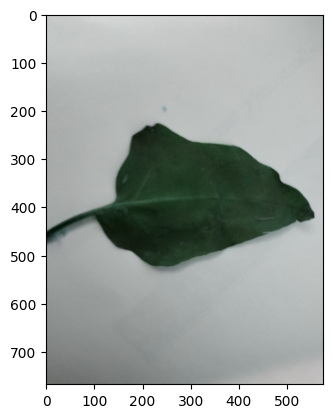

In [43]:
plt.imshow(df['Image'].iloc[0])

In [67]:
print((df['Image'].iloc[0]).shape)

(768, 576, 3)


### **Error with csv dataset**



#### **Trying to show frist image from csv dataset**
**code**

```python
# convert pickle data to csv
data.to_csv('/content/drive/MyDrive/Anveshon project/Plants Images/dataset.csv')

#reading the csv Data
data.to_csv('/content/drive/MyDrive/Anveshon project/Plants Images/dataset.csv')

#checking the Dataset
plt.imshow(data['Image'].iloc[0])
```
**Output:**
```python
---------------------------------------------------------------------------

TypeError                                 Traceback (most recent call last)

<ipython-input-16-2f6e53d0650e> in <cell line: 1>()
----> 1 plt.imshow(data['Image'].iloc[0])

3 frames

/usr/local/lib/python3.10/dist-packages/matplotlib/image.py in set_data(self, A)
    699         if (self._A.dtype != np.uint8 and
    700                 not np.can_cast(self._A.dtype, float, "same_kind")):
--> 701             raise TypeError("Image data of dtype {} cannot be converted to "
    702                             "float".format(self._A.dtype))
    703

TypeError: Image data of dtype <U629 cannot be converted to float
```
#### **Checking the Image pixel Values**
**code**

```python
data["Image"].iloc[0]
# This is formatted as code
```
**output:**

```python
'[[[ 14  41  38]\n  [ 30  57  54]\n  [ 42  69  66]\n  ...\n  [216 192 202]\n  [214 193 202]\n  [214 193 202]]\n\n [[ 20  44  42]\n  [ 73  97  95]\n  [ 78 102 100]\n  ...\n  [216 192 202]\n  [214 193 202]\n  [215 194 203]]\n\n [[ 10  31  29]\n  [ 50  71  69]\n  [ 82 103 101]\n  ...\n  [216 192 202]\n  [215 194 203]\n  [215 194 203]]\n\n ...\n\n [[113 140 137]\n  [ 64  91  88]\n  [ 78 105 102]\n  ...\n  [ 57 123 118]\n  [ 66 130 125]\n  [ 60 124 119]]\n\n [[ 94 121 117]\n  [ 69  96  92]\n  [102 126 124]\n  ...\n  [ 38 104  99]\n  [ 61 124 122]\n  [ 52 115 113]]\n\n [[ 73 100  96]\n  [ 89 116 112]\n  [113 137 135]\n  ...\n  [ 49 115 110]\n  [ 61 124 122]\n  [ 58 121 119]]]'
```

**Reason:**
```
TypeError: Image data of dtype <U629 cannot be converted to float. So The image pixles are in string.
```

#### **Trying to Convert the sring value to float**

**code**
```python
plt.imshow(np.array(data['Image'].iloc[0]).astype(float))
```

**output**
```python
---------------------------------------------------------------------------

ValueError                                Traceback (most recent call last)

<ipython-input-17-4264238dbf8a> in <cell line: 1>()
----> 1 plt.imshow(np.array(data['Image'].iloc[0]).astype(float))

ValueError: could not convert string to float: '[[[ 14  41  38]\n  [ 30  57  54]\n  [ 42  69  66]\n  ...\n  [216 192 202]\n  [214 193 202]\n  [214 193 202]]\n\n [[ 20  44  42]\n  [ 73  97  95]\n  [ 78 102 100]\n  ...\n  [216 192 202]\n  [214 193 202]\n  [215 194 203]]\n\n [[ 10  31  29]\n  [ 50  71  69]\n  [ 82 103 101]\n  ...\n  [216 192 202]\n  [215 194 203]\n  [215 194 203]]\n\n ...\n\n [[113 140 137]\n  [ 64  91  88]\n  [ 78 105 102]\n  ...\n  [ 57 123 118]\n  [ 66 130 125]\n  [ 60 124 119]]\n\n [[ 94 121 117]\n  [ 69  96  92]\n  [102 126 124]\n  ...\n  [ 38 104  99]\n  [ 61 124 122]\n  [ 52 115 113]]\n\n [[ 73 100  96]\n  [ 89 116 112]\n  [113 137 135]\n  ...\n  [ 49 115 110]\n  [ 61 124 122]\n  [ 58 121 119]]]'
```
**code**
```python
from ast import literal_eval
data['Image'] = data['Image'].apply(literal_evl)
```
**output**
```python
Traceback (most recent call last):

  File "/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)

  File "<ipython-input-21-3ce86cf45328>", line 1, in <cell line: 1>
    data['Image'] = data['Image'].apply(literal_eval)

  File "/usr/local/lib/python3.10/dist-packages/pandas/core/series.py", line 4771, in apply
    return SeriesApply(self, func, convert_dtype, args, kwargs).apply()

  File "/usr/local/lib/python3.10/dist-packages/pandas/core/apply.py", line 1123, in apply
    return self.apply_standard()

  File "/usr/local/lib/python3.10/dist-packages/pandas/core/apply.py", line 1174, in apply_standard
    mapped = lib.map_infer(

  File "pandas/_libs/lib.pyx", line 2924, in pandas._libs.lib.map_infer

  File "/usr/lib/python3.10/ast.py", line 64, in literal_eval
    node_or_string = parse(node_or_string.lstrip(" \t"), mode='eval')

  File "/usr/lib/python3.10/ast.py", line 50, in parse
    return compile(source, filename, mode, flags,

  File "<unknown>", line 1
    [[[ 14  41  38]
        ^
SyntaxError: invalid syntax. Perhaps you forgot a comma?
```




### **Loading Pickel dataset**

In [46]:
x=df['Image'].iloc[0:200]
y=df['Target'].iloc[0:200]

In [39]:
x= x/255.0

In [55]:
train_x,test_x,y_train,y_test= train_test_split(x,y,test_size=0.20,random_state=42)
train_x,val_x,y_train,y_val=train_test_split(train_x,y_train,test_size=0.1,random_state=42)

In [64]:
print(train_x)

1628    [[[189, 208, 129], [188, 207, 128], [187, 206,...
1261    [[[115, 173, 144], [115, 173, 144], [117, 172,...
1082    [[[79, 73, 44], [80, 74, 45], [82, 75, 48], [8...
1591    [[[21, 168, 106], [16, 165, 102], [13, 162, 99...
1079    [[[19, 37, 44], [19, 37, 44], [19, 38, 46], [2...
                              ...                        
1231    [[[199, 201, 201], [198, 200, 200], [198, 200,...
380     [[[51, 115, 69], [52, 116, 70], [58, 117, 72],...
227     [[[83, 141, 87], [79, 139, 85], [78, 138, 84],...
732     [[[225, 223, 223], [225, 223, 223], [225, 223,...
318     [[[22, 78, 35], [20, 76, 33], [28, 84, 43], [2...
Name: Image, Length: 144, dtype: object


### **Building Vgg16 model**

In [56]:
Vgg16_base_mdl = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3),classes=9)
Vgg16_base_mdl.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [57]:
#changing the model in to non_trainable.
for layer in Vgg16_base_mdl.layers:
    layer.trainable = False

In [58]:
#model summary after Change non_trainable
Vgg16_base_mdl.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

### **Creating our Neural network**

In [59]:
X = layers.Flatten()(Vgg16_base_mdl.output)
X=layers.Dense(256,activation='relu')(X)
X=layers.Dropout(0.5)(X)

predictions = layers.Dense(9,activation='softmax')(X)
model=models.Model(inputs=Vgg16_base_mdl.input,outputs=predictions)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [62]:
model.fit(train_x,y_train,epochs=10,batch_size=5,validation_data=(val_x,y_val))

ValueError: ignored